In [1]:
import os
os.chdir('/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src')

In [2]:
from operator import itemgetter
from tqdm import tqdm
import time
from datetime import datetime
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import importlib

import seaborn as sns

In [3]:
from dataloaders import dataset_ST_MultiPoint
# from dataloaders import load_dataset
# from loss import losses_SparseData
# from models import models_SparseData
# from optimizer import load_optimizer

from subprocess import Popen

In [4]:
inference_run_path = '/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/test_predictions/STAINet_PSTAINet-IB_PSTAINet-ILB_PSTAINet-ILRB_20251209_100741/predictions'
model_list = ["STAINet","PSTAINet-IB","PSTAINet-ILB","PSTAINet-ILRB"]

# Data

In [5]:
json_file = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/config/ST_MultiPoint_STDisNet_SAGW_PI_ERA5.json" #config_files_1d/lstm_att_1.json
dict_files = {}
with open(json_file) as f:
    dict_files = json.load(f)
    print(f"Read data.json: {dict_files}")

Read data.json: {'cuda_device': 'cuda:0', 'seed': 42, 'entity': 'gsartor-unito', 'experiment_name': 'ST_MultiPoint', 'run_name': 'PI_S_ref', 'comments': None, 'wandb_mode': 'offline', 'wandb_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/logs', 'save_model_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/runs', 'dtm_nc': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dtm_ROI.nc', 'weather_nc_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_2000_2024_weekly.nc', 'weather_dtm': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_dtm.nc', 'wtd_csv_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dataset_wtd_roi.csv', 'wtd_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/underground_wtd_sensor_roi.shp', 'piedmont_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/piemonte_admin_boundaries.shp', 'recharge_areas_shp': '/leonardo_

# Missing Data

In [6]:
ds = dataset_ST_MultiPoint.Dataset_ST_MultiPoint(dict_files)

    Loading weather data... 

/leonardo_scratch/fast/IscrC_DL4STP/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Done!
    Loading dtm... Done!
    Loading Piedmont Shapefiles... 

/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src/dataloaders/dataset_ST_MultiPoint.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  clipped_buffer = clipped.buffer(buffer_recharge)


Done!
    Loading underground water data... Done!
    Norm factors:
{'target_means': np.float64(297.1249160768408), 'target_stds': np.float64(73.38987997145817), 'dtm_mean': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(1139.4907, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'dtm_std': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(884.7991, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'lat_mean': np.float64(44.800499999999964), 'lat_std': np.float64(0.3169655454549103), 'lon_mean': np.float64(7.375499999999998), 'lon_std': np.float64(0.4326943495034695), 'weather_mean': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0
Data variables:
    tp           float32 4B 0.001774
    t2m          float32 4B 280.5
    pev          float32 4B -0.001865
    smlt         float32 4B 0.000512, 'weather_std': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0

In [7]:
ds.wtd_df["h"].isna().groupby(level='sensor_id').sum()

sensor_id
00103510001    140
00104110001    453
00105110001    473
00105910001     42
00105910002    100
00107010001    264
00109010001    247
00112710001    282
00117110001    370
00119710001    923
00126010001     52
00127210001     57
00127210003    433
00131010001    390
00401210001      7
00402910001    271
00403410001    299
00404110001    643
00405910001    374
00407810001    118
00408910001    173
00408910002    252
00414310002    157
00417910001     70
00421510001    262
00421710001    382
00422510001     71
00425010001    321
Name: h, dtype: int64

In [8]:
ds.wtd_df.index.get_level_values(0).unique().size

1200

In [9]:
gw_ns_perc = ds.wtd_df["h"].isna().groupby(level='sensor_id').sum()/ds.wtd_df.index.get_level_values(0).unique().size
gw_ns_perc.name = "perc_missing"

In [10]:
gw_ns_perc.mean()

np.float64(0.22696428571428576)

In [11]:
gw_ns_perc.median()

np.float64(0.21916666666666668)

In [12]:
gw_ns_perc

sensor_id
00103510001    0.116667
00104110001    0.377500
00105110001    0.394167
00105910001    0.035000
00105910002    0.083333
00107010001    0.220000
00109010001    0.205833
00112710001    0.235000
00117110001    0.308333
00119710001    0.769167
00126010001    0.043333
00127210001    0.047500
00127210003    0.360833
00131010001    0.325000
00401210001    0.005833
00402910001    0.225833
00403410001    0.249167
00404110001    0.535833
00405910001    0.311667
00407810001    0.098333
00408910001    0.144167
00408910002    0.210000
00414310002    0.130833
00417910001    0.058333
00421510001    0.218333
00421710001    0.318333
00422510001    0.059167
00425010001    0.267500
Name: perc_missing, dtype: float64

In [13]:
munic_ds = ds.wtd_geodf.loc[:,["sensor_id","munic"]].set_index("sensor_id")
munic_ds

,munic
sensor_id,
00103510001,Bricherasio
00104110001,Buriasco
00105110001,Candiolo
00105910001,Carmagnola
00105910002,Carmagnola
00107010001,Cavour
00109010001,Collegno
00112710001,La Loggia
00117110001,Orbassano


In [14]:
munic_missing_ds = pd.merge(munic_ds, gw_ns_perc*100, left_index=True, right_index=True)
munic_missing_ds

,munic,perc_missing
sensor_id,,
00103510001,Bricherasio,11.666667
00104110001,Buriasco,37.750000
00105110001,Candiolo,39.416667
00105910001,Carmagnola,3.500000
00105910002,Carmagnola,8.333333
00107010001,Cavour,22.000000
00109010001,Collegno,20.583333
00112710001,La Loggia,23.500000
00117110001,Orbassano,30.833333


In [15]:
munic_missing_ds["label"] = munic_missing_ds["munic"] + " - " + munic_missing_ds.index.astype(str)
munic_missing_ds

,munic,perc_missing,label
sensor_id,,,
00103510001,Bricherasio,11.666667,Bricherasio - 00103510001
00104110001,Buriasco,37.750000,Buriasco - 00104110001
00105110001,Candiolo,39.416667,Candiolo - 00105110001
00105910001,Carmagnola,3.500000,Carmagnola - 00105910001
00105910002,Carmagnola,8.333333,Carmagnola - 00105910002
00107010001,Cavour,22.000000,Cavour - 00107010001
00109010001,Collegno,20.583333,Collegno - 00109010001
00112710001,La Loggia,23.500000,La Loggia - 00112710001
00117110001,Orbassano,30.833333,Orbassano - 00117110001


In [16]:
# Sort sensors by missing percentage
df_sorted = munic_missing_ds.sort_values("perc_missing")

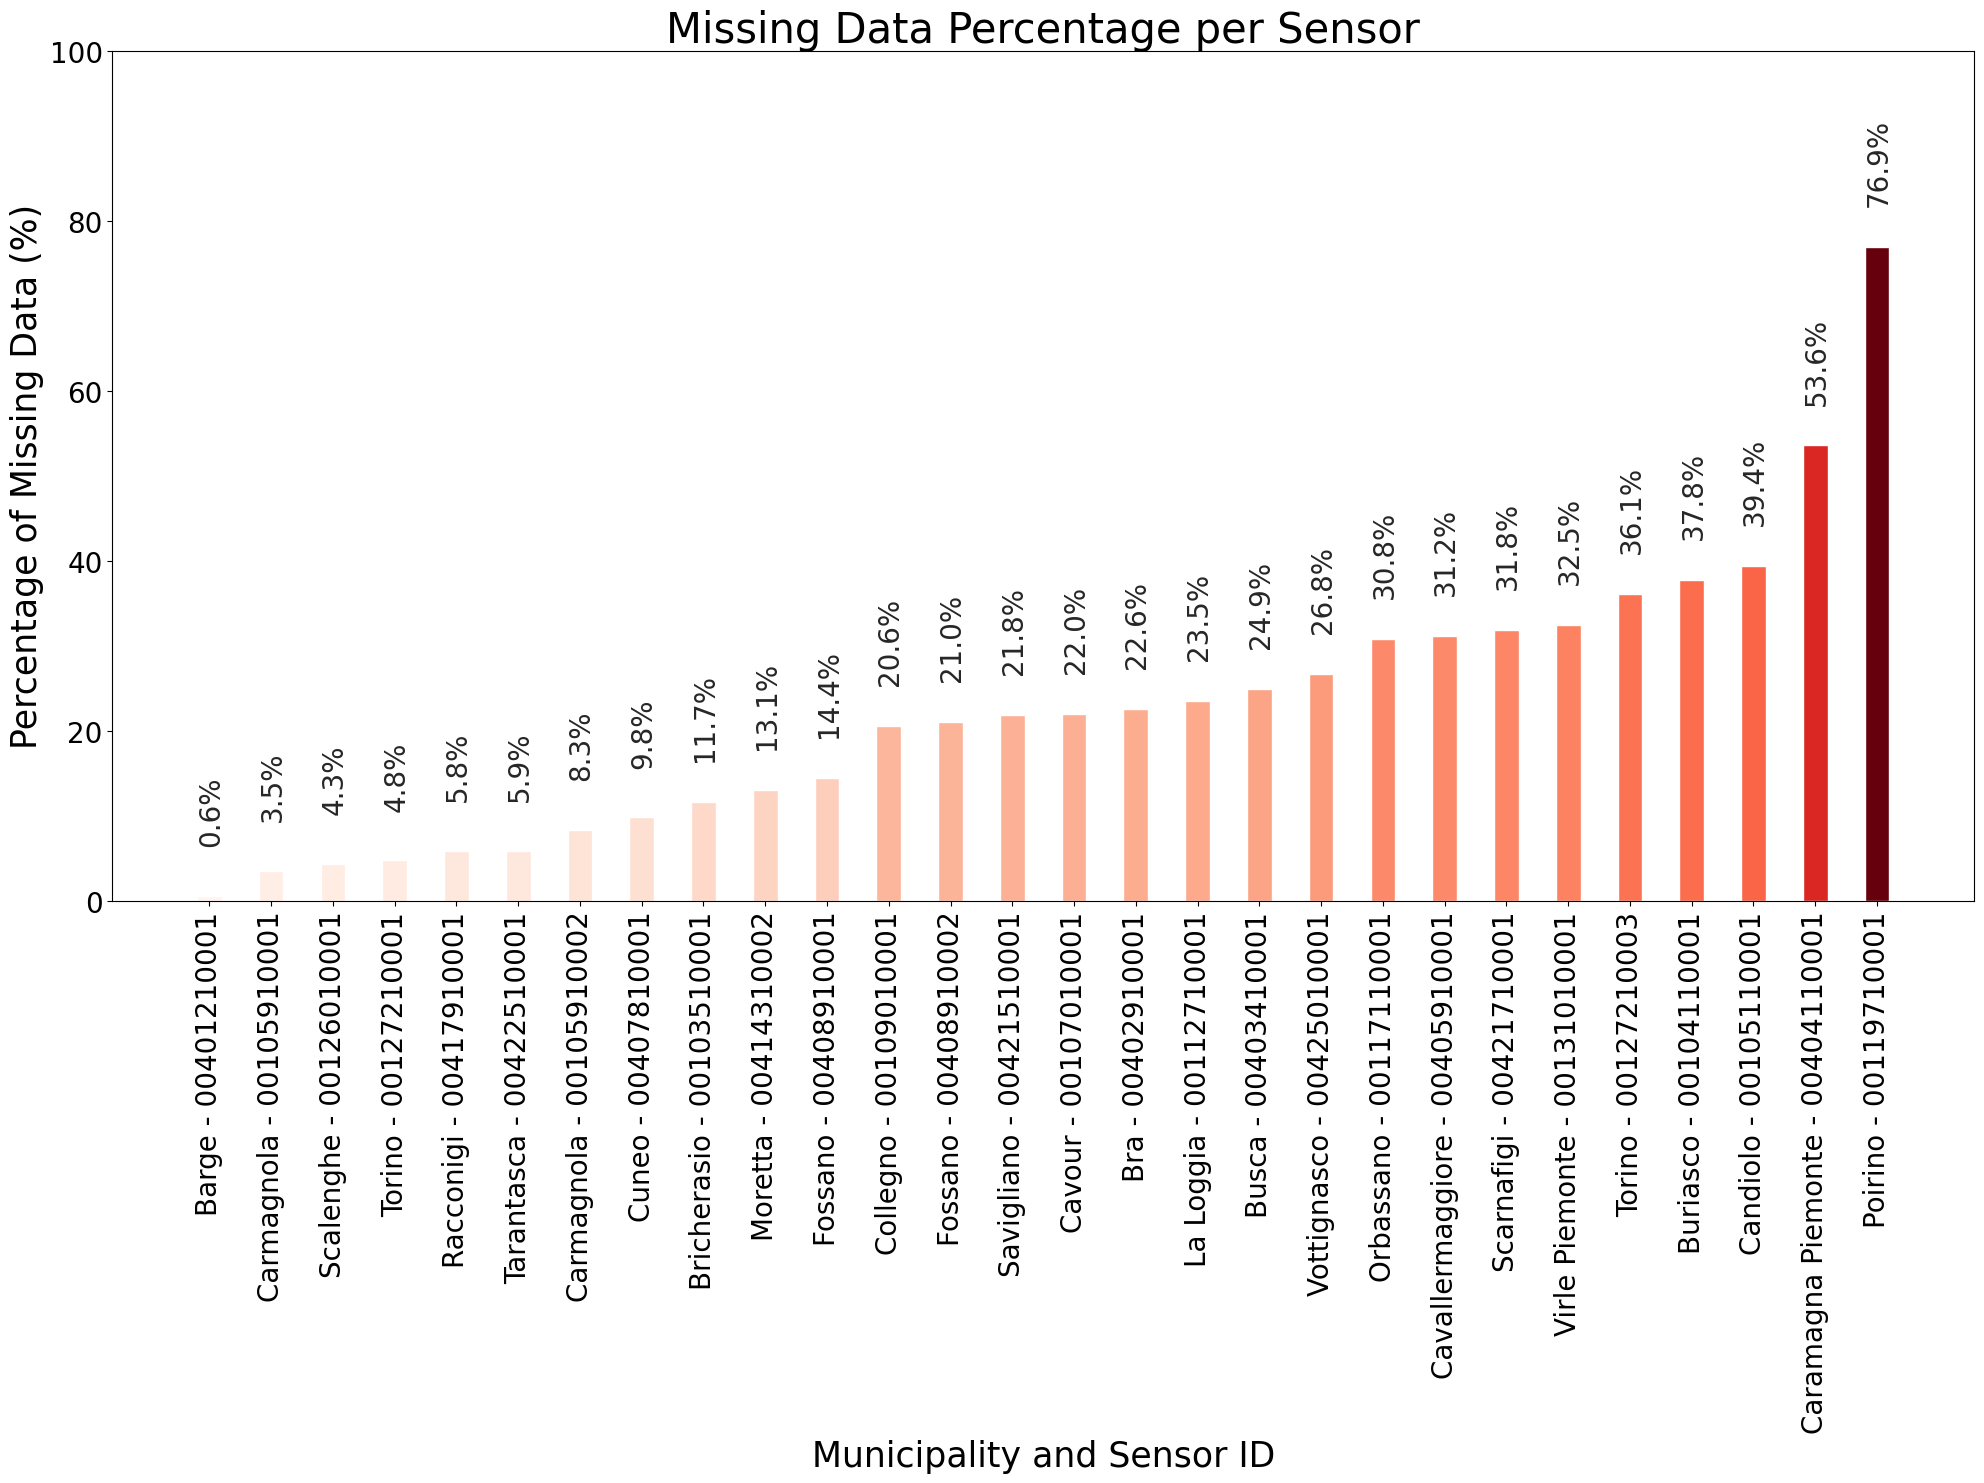

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: your dataframe is something like:
# df.index = sensor_id
# df['missing_pct'] = percentage of missing values

plt.rcParams.update({'font.size': 20,
                         'ytick.labelsize': 20,
                         'xtick.labelsize': 20})

fig, ax = plt.subplots(figsize=(20, 15))
sns.set_theme(style="whitegrid")

# Color map based on missing percentage
colors = sns.color_palette("Reds", as_cmap=True)

bars = ax.bar(
    df_sorted["label"],
    df_sorted["perc_missing"],
    width=0.4,
    color=colors(df_sorted["perc_missing"] / df_sorted["perc_missing"].max())
)

# for label in ax.get_yticklabels():
#     label.set_linespacing(0.9)

plt.xticks(rotation=90)

# Annotate each bar with the percentage value
for bar, pct in zip(bars, df_sorted["perc_missing"]):
    ax.text(
        bar.get_x(),
        bar.get_height() + 10,
        f"{pct:.1f}%",
        va='center',
        fontsize=20,
        rotation=90
    )

plt.ylim(0,100)
plt.xlabel("Municipality and Sensor ID", fontsize=25)
plt.ylabel("Percentage of Missing Data (%)", fontsize=25)
plt.title("Missing Data Percentage per Sensor", fontsize=30,
          #weight='bold'
          )
plt.tight_layout()

#plt.savefig("/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/sensor_analysis/missing_perc.jpeg", dpi = 600, transparent = True, bbox_inches = 'tight' )

## Train - Val - Test Count

In [18]:
training_ds = ds.wtd_df.loc[pd.IndexSlice[:np.datetime64("2019-12-31"), :],:]
val_ds = ds.wtd_df.loc[pd.IndexSlice[np.datetime64("2020-01-01"):np.datetime64("2021-12-31"), :],:]
test_ds = ds.wtd_df.loc[pd.IndexSlice[np.datetime64("2022-01-01"):, :],:]

In [19]:
val_ds.index.get_level_values(0).unique()

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2021-10-24', '2021-10-31', '2021-11-07', '2021-11-14',
               '2021-11-21', '2021-11-28', '2021-12-05', '2021-12-12',
               '2021-12-19', '2021-12-26'],
              dtype='datetime64[ns]', name='date', length=104, freq=None)

In [20]:
training_ds_count = (~training_ds["h"].isna()).groupby(level='sensor_id').sum()
val_ds_count = (~val_ds["h"].isna()).groupby(level='sensor_id').sum()
test_ds_count = (~test_ds["h"].isna()).groupby(level='sensor_id').sum()

In [21]:
training_ds_count

sensor_id
00103510001    895
00104110001    665
00105110001    526
00105910001    950
00105910002    892
00107010001    768
00109010001    745
00112710001    769
00117110001    749
00119710001    277
00126010001    940
00127210001    948
00127210003    559
00131010001    602
00401210001    985
00402910001    830
00403410001    896
00404110001    532
00405910001    826
00407810001    874
00408910001    971
00408910002    740
00414310002    835
00417910001    922
00421510001    778
00421710001    694
00422510001    922
00425010001    671
Name: h, dtype: int64

In [22]:
ds_tot_count = pd.concat([training_ds_count, val_ds_count, test_ds_count], axis=1)
ds_tot_count.columns = ["train_count", "val_count", "test_count"]

In [23]:
ds_tot_count

,train_count,val_count,test_count
sensor_id,,,
00103510001,895,66,99
00104110001,665,64,18
00105110001,526,103,98
00105910001,950,104,104
00105910002,892,104,104
00107010001,768,104,64
00109010001,745,104,104
00112710001,769,60,89
00117110001,749,61,20


In [24]:
ds_tot_count = pd.merge(munic_ds, ds_tot_count, left_index=True, right_index=True)
ds_tot_count["label"] = ds_tot_count["munic"] + " - " + ds_tot_count.index.astype(str)
ds_tot_count

,munic,train_count,val_count,test_count,label
sensor_id,,,,,
00103510001,Bricherasio,895,66,99,Bricherasio - 00103510001
00104110001,Buriasco,665,64,18,Buriasco - 00104110001
00105110001,Candiolo,526,103,98,Candiolo - 00105110001
00105910001,Carmagnola,950,104,104,Carmagnola - 00105910001
00105910002,Carmagnola,892,104,104,Carmagnola - 00105910002
00107010001,Cavour,768,104,64,Cavour - 00107010001
00109010001,Collegno,745,104,104,Collegno - 00109010001
00112710001,La Loggia,769,60,89,La Loggia - 00112710001
00117110001,Orbassano,749,61,20,Orbassano - 00117110001


In [25]:
ds_tot_count = ds_tot_count.loc[df_sorted.index]

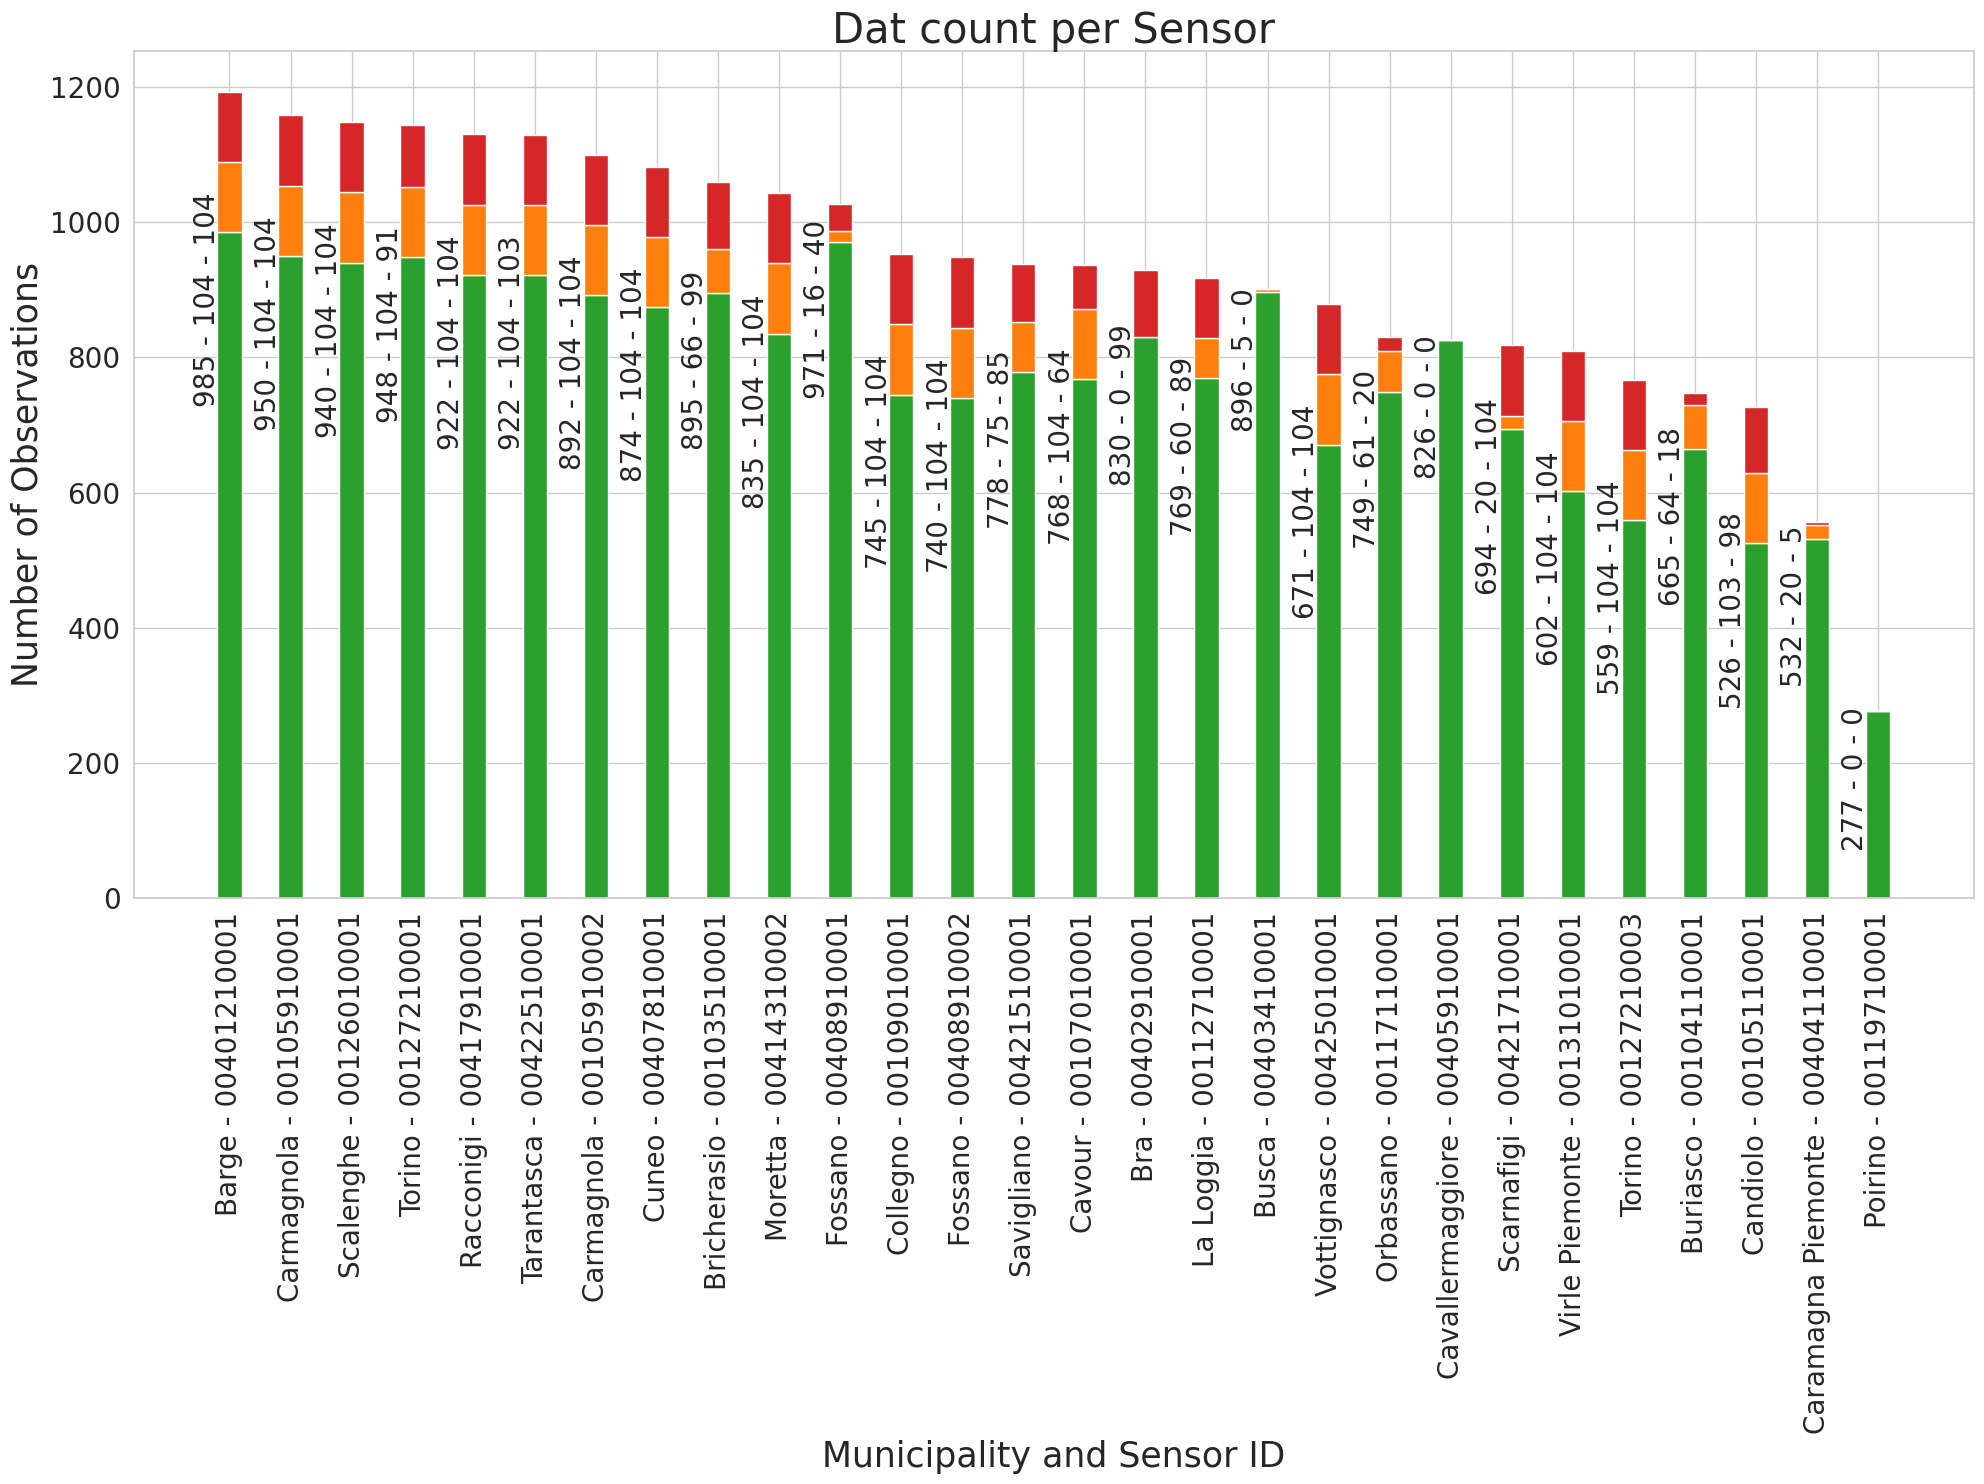

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: your dataframe is something like:
# df.index = sensor_id
# df['missing_pct'] = percentage of missing values

plt.rcParams.update({'font.size': 20,
                         'ytick.labelsize': 20,
                         'xtick.labelsize': 20})

# Sort sensors by missing percentage

fig, ax = plt.subplots(figsize=(20, 15))
sns.set_theme(style="whitegrid")

# Color map based on missing percentage
colors = sns.color_palette("Greys", as_cmap=True)

bars_train = ax.bar(
    ds_tot_count["label"],
    ds_tot_count["train_count"],
    width=0.4,  
    color="tab:green",
    label = "training"
)

bars_val = ax.bar(
    ds_tot_count["label"],
    ds_tot_count["val_count"],
    width=0.4,
    bottom=ds_tot_count["train_count"],
    color="tab:orange",
    label = "validation"
)

bars_test = ax.bar(
    ds_tot_count["label"],
    ds_tot_count["test_count"],
    width=0.4,
    bottom=ds_tot_count["train_count"]+ds_tot_count["val_count"],
    color="tab:red",
    label = "test"
)

# for label in ax.get_yticklabels():
#     label.set_linespacing(0.9)

plt.xticks(rotation=90)
# plt.yticks([0,500,1000],
#           [0,500,1000])

# Annotate each bar with the percentage value
for i in range(len(bars_train)):
    ax.text(
        bars_train[i].get_x()-0.4,
        bars_train[i].get_height()-100,
        f"{ds_tot_count['train_count'].iloc[i]} - {ds_tot_count['val_count'].iloc[i]} - {ds_tot_count['test_count'].iloc[i]}",
        va='center',
        fontsize=20,
        rotation=90
    )

#plt.ylim(0,100)
plt.xlabel("Municipality and Sensor ID", fontsize=25)
plt.ylabel("Number of Observations", fontsize=25)
plt.title("Dat count per Sensor", fontsize=30,
          #weight='bold'
          )
plt.tight_layout()
plt.savefig("/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/sensor_analysis/number_observations.jpeg", dpi = 600, transparent = True, bbox_inches = 'tight' )

# Metric Boxplots - per metric

In [117]:
metric_path = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/test_predictions/STAINet_PSTAINet-IB_PSTAINet-ILB_PSTAINet-ILRB_20251209_100741/metrics"
metrics = ["nbias", "rmse", "mape", "nse", "kge"]
models = ["STAINet", "PSTAINet-IB", "PSTAINet-ILB", "PSTAINet-ILRB"]

In [118]:
# load all metrics for all models
model_metrics_dict = {}

for metric in metrics:
    ds_list = []
    for model in models:
        tmp_ds = pd.read_csv(f"{metric_path}/{model}_{metric}.csv",
                                parse_dates=True,
                                )
        
        tmp_ds.columns = ["id_sensor", model]
        tmp_ds["id_sensor"] = tmp_ds["id_sensor"].astype(str)
        tmp_ds = tmp_ds.set_index("id_sensor")
        ds_list.append(tmp_ds)
        
    model_metrics_dict[metric] = pd.concat(ds_list, axis=1)
    


In [119]:
model_metrics_dict["nse"]

,STAINet,PSTAINet-IB,PSTAINet-ILB,PSTAINet-ILRB
id_sensor,,,,
103510001,0.561779,0.459157,0.823435,0.662727
104110001,0.378075,0.807650,0.900652,0.926679
105110001,0.556324,0.853483,0.607348,0.856921
105910001,0.695904,0.730360,0.889710,0.904352
105910002,0.725492,0.803444,0.771175,0.367740
107010001,0.570831,0.718781,0.765767,0.741526
109010001,0.710991,0.880923,0.897677,0.826001
112710001,-5.012445,-2.616736,-9.122133,-8.331291
117110001,0.621689,0.906283,0.980590,0.967074


In [62]:
import seaborn as sns

In [78]:
sns.load_dataset("titanic")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [143]:
metrics

['nbias', 'rmse', 'mape', 'nse', 'kge']

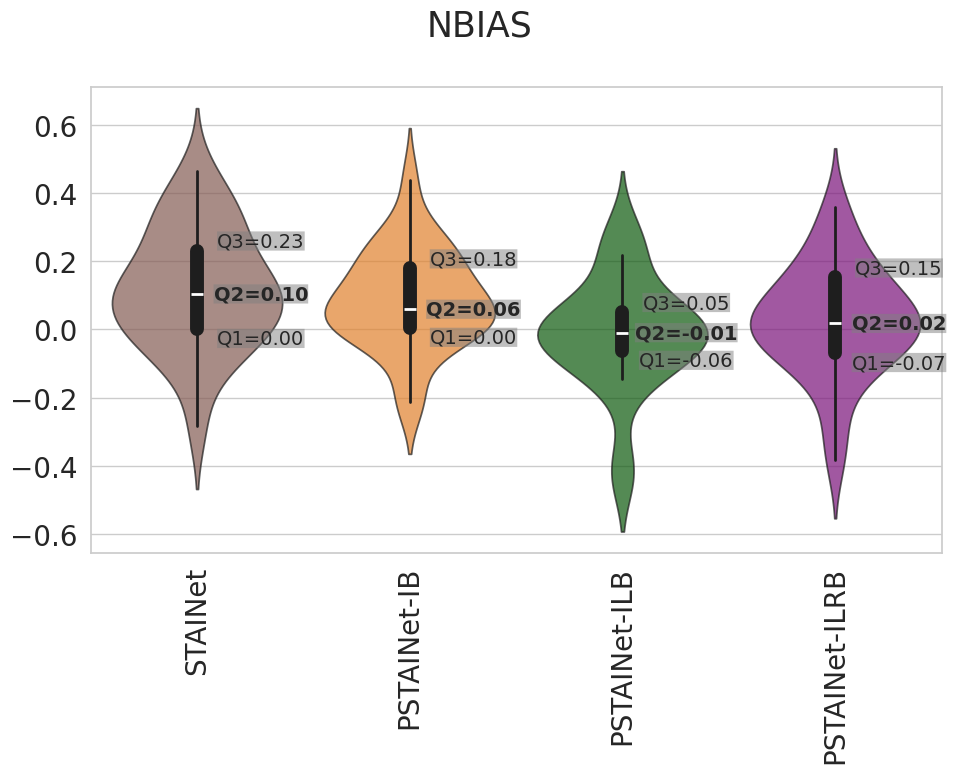

In [173]:
i = 0
plt.rcParams.update({'font.size': 20,
                         'ytick.labelsize': 20,
                         'xtick.labelsize': 20})

fig, ax = plt.subplots(figsize = (10,8))
fig.suptitle(metrics[i].upper(), fontsize=25)
violin = sns.violinplot(model_metrics_dict[metrics[i]].dropna(),
            inner="box",
            inner_kws={'box_width':10, 'whis_width':2},
            density_norm = "width",
            alpha = 0.7,
            palette = ["tab:brown","tab:orange","darkgreen","darkmagenta"],
            ax = ax)

plt.xticks(rotation=90)

# Common textbox style
bbox_style = dict(
    boxstyle="round,pad=0.005",
    facecolor="grey",
    edgecolor="none",
    alpha=0.5
)

# Add annotations
for (j, model) in enumerate(models):
    
    values = model_metrics_dict[metrics[i]][model].dropna()
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)

    ax.text(j+0.3, q1, f"Q1={q1:.2f}",
            ha='center', va='top', fontsize=14, bbox=bbox_style)

    ax.text(j+0.3, q2, f"Q2={q2:.2f}",
            ha='center', va='center', fontsize=14,
            fontweight='bold', bbox=bbox_style)

    ax.text(j+0.3, q3, f"Q3={q3:.2f}",
            ha='center', va='bottom', fontsize=14, bbox=bbox_style)

plt.tight_layout()
plt.show()


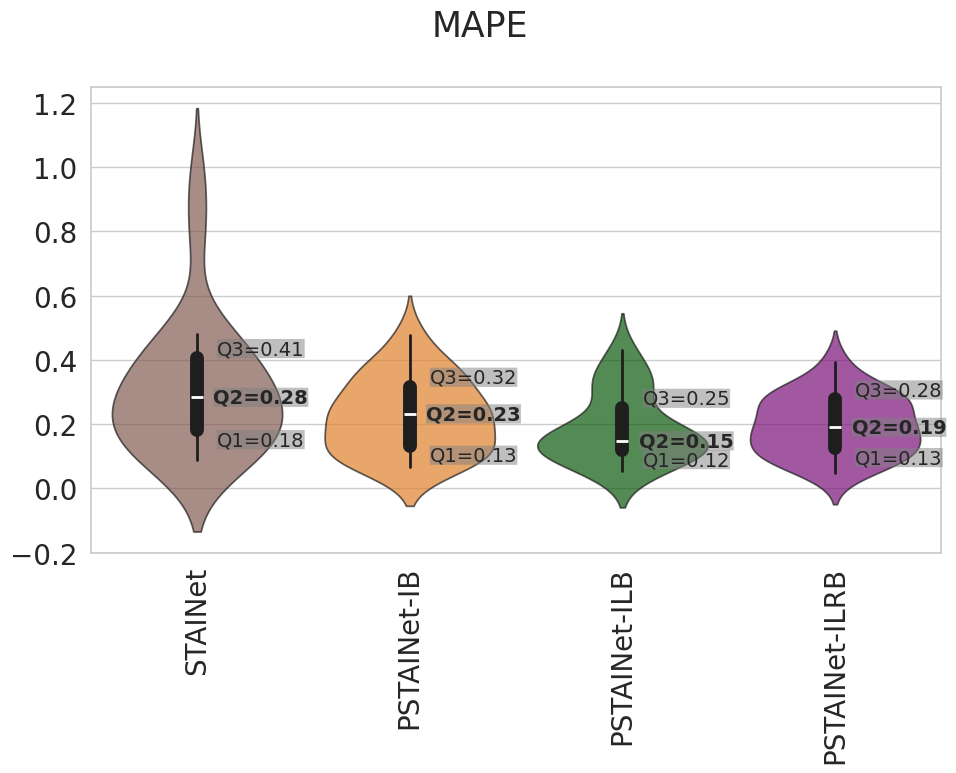

In [172]:
i = 2
plt.rcParams.update({'font.size': 20,
                         'ytick.labelsize': 20,
                         'xtick.labelsize': 20})

fig, ax = plt.subplots(figsize = (10,8))
fig.suptitle(metrics[i].upper(), fontsize=25)
violin = sns.violinplot(model_metrics_dict[metrics[i]].dropna(),
            inner="box",
            inner_kws={'box_width':10, 'whis_width':2},
            density_norm = "width",
            alpha = 0.7,
            palette = ["tab:brown","tab:orange","darkgreen","darkmagenta"],
            ax = ax)

plt.xticks(rotation=90)

# Common textbox style
bbox_style = dict(
    boxstyle="round,pad=0.005",
    facecolor="grey",
    edgecolor="none",
    alpha=0.5
)

# Add annotations
for (j, model) in enumerate(models):
    
    values = model_metrics_dict[metrics[i]][model].dropna()
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)

    ax.text(j+0.3, q1, f"Q1={q1:.2f}",
            ha='center', va='top', fontsize=14, bbox=bbox_style)

    ax.text(j+0.3, q2, f"Q2={q2:.2f}",
            ha='center', va='center', fontsize=14,
            fontweight='bold', bbox=bbox_style)

    ax.text(j+0.3, q3, f"Q3={q3:.2f}",
            ha='center', va='bottom', fontsize=14, bbox=bbox_style)

plt.tight_layout()
plt.show()

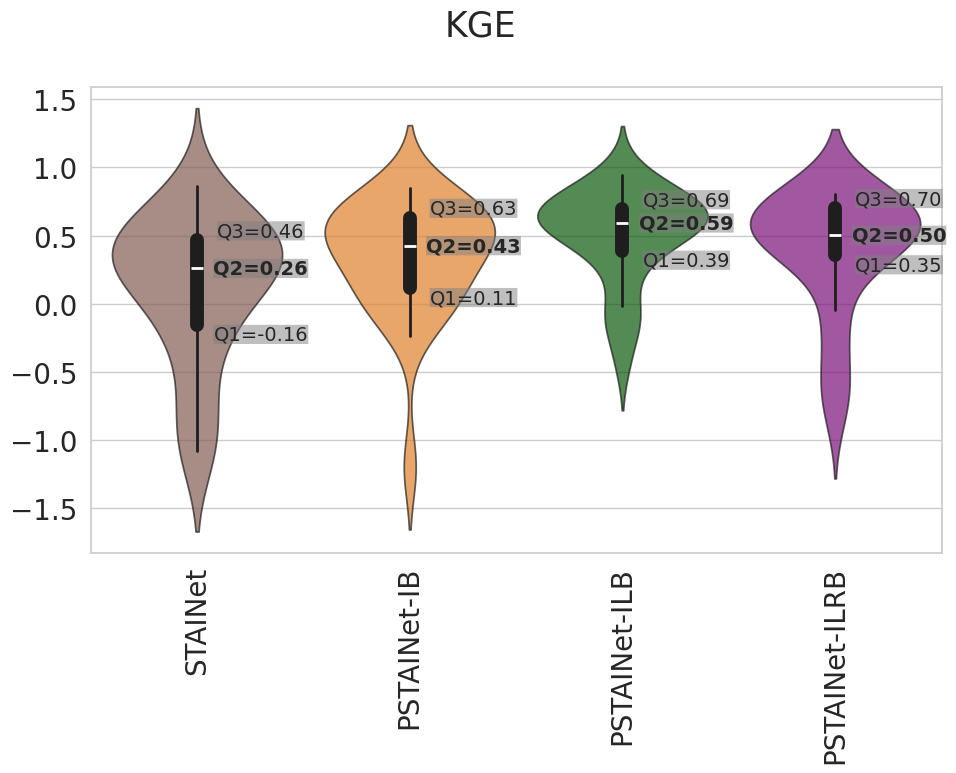

In [176]:
i = -1
plt.rcParams.update({'font.size': 20,
                         'ytick.labelsize': 20,
                         'xtick.labelsize': 20})

fig, ax = plt.subplots(figsize = (10,8))
fig.suptitle(metrics[i].upper(), fontsize=25)
violin = sns.violinplot(model_metrics_dict[metrics[i]].dropna(),
            inner="box",
            inner_kws={'box_width':10, 'whis_width':2},
            density_norm = "width",
            alpha = 0.7,
            palette = ["tab:brown","tab:orange","darkgreen","darkmagenta"],
            ax = ax)

plt.xticks(rotation=90)

# Common textbox style
bbox_style = dict(
    boxstyle="round,pad=0.005",
    facecolor="grey",
    edgecolor="none",
    alpha=0.5
)

# Add annotations
for (j, model) in enumerate(models):
    
    values = model_metrics_dict[metrics[i]][model].dropna()
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)

    ax.text(j+0.3, q1, f"Q1={q1:.2f}",
            ha='center', va='top', fontsize=14, bbox=bbox_style)

    ax.text(j+0.3, q2, f"Q2={q2:.2f}",
            ha='center', va='center', fontsize=14,
            fontweight='bold', bbox=bbox_style)

    ax.text(j+0.3, q3, f"Q3={q3:.2f}",
            ha='center', va='bottom', fontsize=14, bbox=bbox_style)

plt.tight_layout()
plt.show()